### Baseline
Estableceremos nuestro modelo base como modelo que prediga todos los casos como no incendios

In [35]:
import extraccion.minioFunctions as mf
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

##### Carga de datos
Nos traemos nuestro dataframe final limpio y preprocesado

In [20]:
cliente = mf.crear_cliente()
df = mf.bajar_fichero(cliente, "grupo3/cleaned/final_date_transformado.parquet")

#Dividimos en variable explicativa y respuesta
df2 = df.copy()
y = df2["final"]
df2.drop(columns = ["final"], inplace = True)
X = df2

Dataframe importado correctamente


### Agrupamos variables por rango de valores
Para la hora de crear nuestros modelos, nos vendrá bien saber si para determinados modelos será necesario estandarizar.

C:\Users\PC\AppData\Local\Temp\ipykernel_12800\1737083500.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


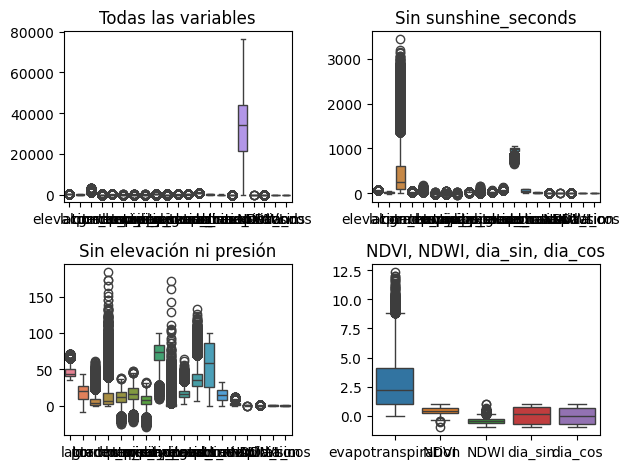

In [66]:
fig, ax = plt.subplots(nrows = 2, ncols = 2)
sns.boxplot(data = X_train, ax=ax[0,0])

X_vis = X_train.drop(columns=["sunshine_seconds"])
sns.boxplot(data = X_vis, ax=ax[0,1])

X_vis2 = X_vis.drop(columns=["elevacion_centro", "pressure_mean"])
sns.boxplot(data = X_vis2, ax=ax[1,0])

X_vis3 = X_vis2[["evapotranspiration", "NDVI", "NDWI", "dia_sin", "dia_cos"]]
sns.boxplot(data = X_vis3, ax=ax[1,1])

ax[0,0].set_title("Todas las variables")
ax[0,1].set_title("Sin sunshine_seconds")
ax[1,0].set_title("Sin elevación ni presión")
ax[1,1].set_title("NDVI, NDWI, dia_sin, dia_cos")

plt.tight_layout()

fig.show()

##### Conclusiones
Para los modelos que entrenemos que utilicen distancias entre datos (regresión logística, regresión lineal o knn), necesitaremos estandarizar los datos.

### Baseline riesgo incendios
Miramos la proporción de la clase mayoritaria con respecto a la de incendios

In [ ]:
filtro = (y == 1)
no_incendios = len(y[filtro])
incendios = len(y[~filtro])

prop_incendios = no_incendios / (no_incendios + incendios)
prop_no_incendios = incendios / (no_incendios + incendios)

print(f"===== Incendios y no incendios ===== \n")
print(f"No incendios: {no_incendios}")
print(f"Incendios: {incendios}\n")

print(f"===== Proporción =====\n")
print(f"No incendios: {round(prop_no_incendios * 100, 2)}%")
print(f"Incendios: {round(prop_incendios * 100, 2)}%")

===== Incendios y no incendios ===== 

No incendios: 2685
Incendios: 68760

===== Proporción =====

No incendios: 96.24%
Incendios: 3.76%


##### Conclusiones
Nuestra clase mayoritaria es notablemente la de no incendios por lo que un accuracy muy alto no nos aporta gran información porque nuestro baseline tendría un accuracy del 96.24%

Necesitaremos que nuestro modelo de predicción de riesgo maximice la cantidad de incendios predichos como incendios (falsos negativos) y por ello tendremos que maximizar nuestro **RECALL**.